In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("/kaggle/input/breast-cancer-dataset/breast-cancer.csv")
df = df.drop(columns=['id'])
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [3]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

In [5]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [6]:
print("Class distribution:")
print(y.value_counts())
print(f"\nClass balance: {y.value_counts(normalize=True).round(2).to_dict()}")

Class distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64

Class balance: {0: 0.63, 1: 0.37}


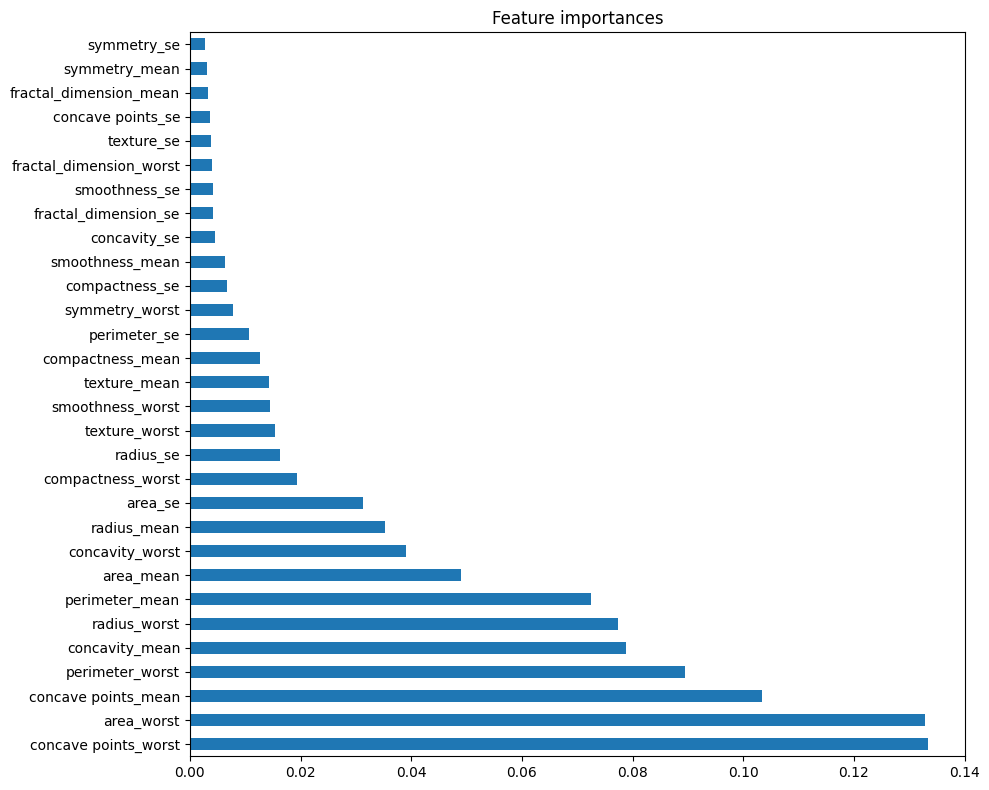

In [7]:
rf_selector = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_selector.fit(X, y)

importances = pd.Series(rf_selector.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.plot(kind='barh')
plt.title('Feature importances')
plt.tight_layout()
plt.show()

In [8]:
top_features = importances.head(15).index.tolist()
X_selected = X[top_features]
print(f"\nKept features: {top_features}")


Kept features: ['concave points_worst', 'area_worst', 'concave points_mean', 'perimeter_worst', 'concavity_mean', 'radius_worst', 'perimeter_mean', 'area_mean', 'concavity_worst', 'radius_mean', 'area_se', 'compactness_worst', 'radius_se', 'texture_worst', 'smoothness_worst']


In [9]:
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',   # handles imbalance
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for metric in ['accuracy', 'precision', 'recall', 'f1']:
    scores = cross_val_score(model, X_selected, y, cv=cv, scoring=metric)
    print(f"{metric:12s}: {scores.mean():.3f} ± {scores.std():.3f}")

accuracy    : 0.958 ± 0.019
precision   : 0.953 ± 0.031
recall      : 0.934 ± 0.052
f1          : 0.943 ± 0.028


In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))


Classification report:
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



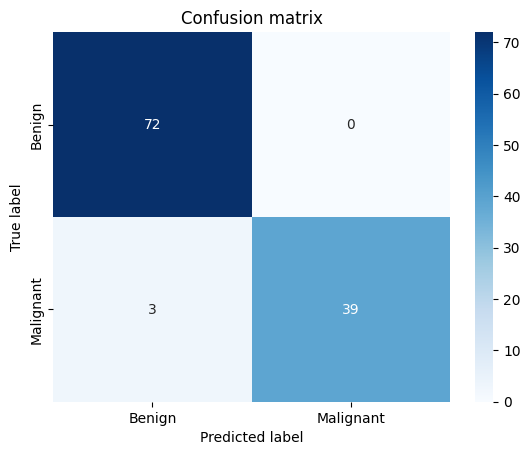

In [11]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title('Confusion matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [12]:
import shap
import matplotlib.pyplot as plt

model.fit(X_train, y_train)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# ── Fix: handle both old and new SHAP output formats ──────
import numpy as np
if isinstance(shap_values, list):
    # Old SHAP: list of 2 arrays, one per class
    shap_malignant = shap_values[1]
else:
    # New SHAP: single 3D array of shape (n_samples, n_features, n_classes)
    shap_malignant = shap_values[:, :, 1]

print(f"shap_values type: {type(shap_values)}")
print(f"shap_malignant shape: {shap_malignant.shape}")
print(f"X_test shape: {X_test.shape}")
# These two should now match: (n_samples, n_features)

shap_values type: <class 'numpy.ndarray'>
shap_malignant shape: (114, 15)
X_test shape: (114, 15)


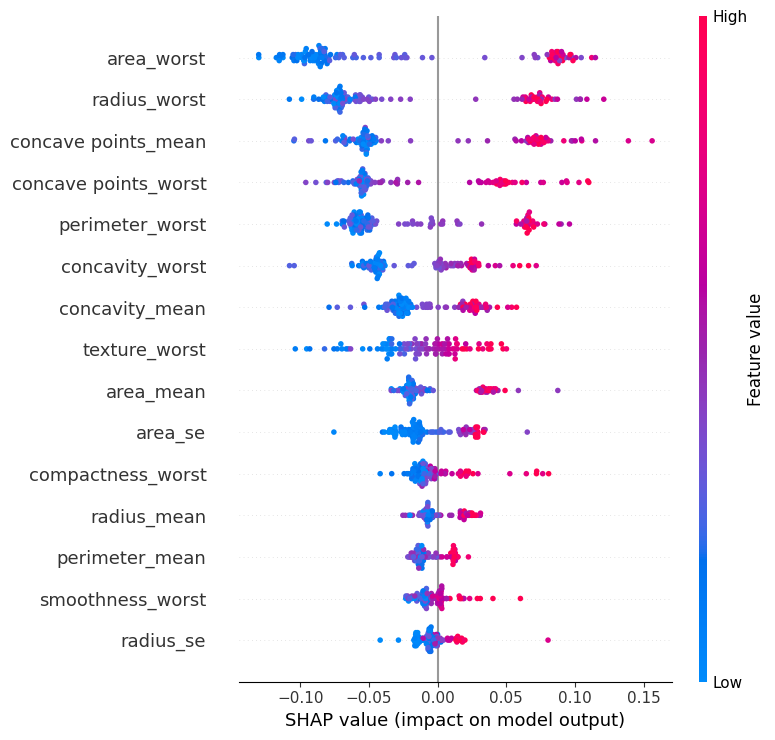

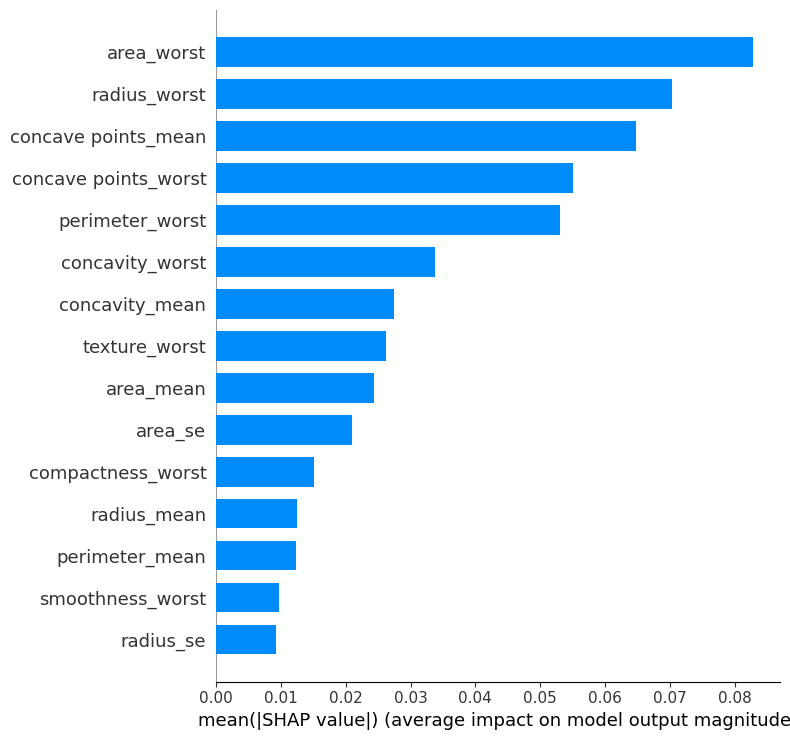

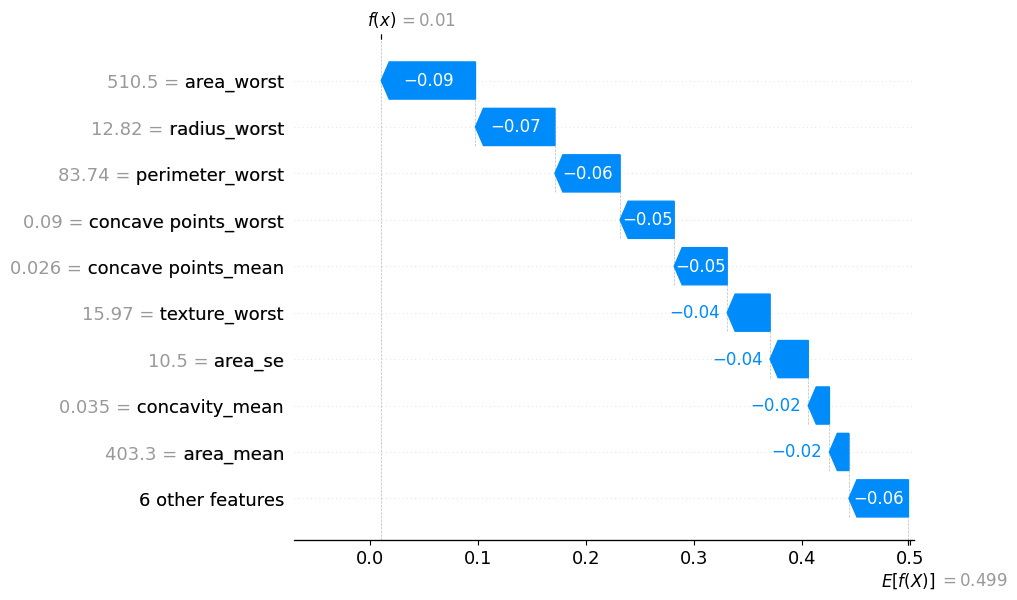


── False negative 1 ──


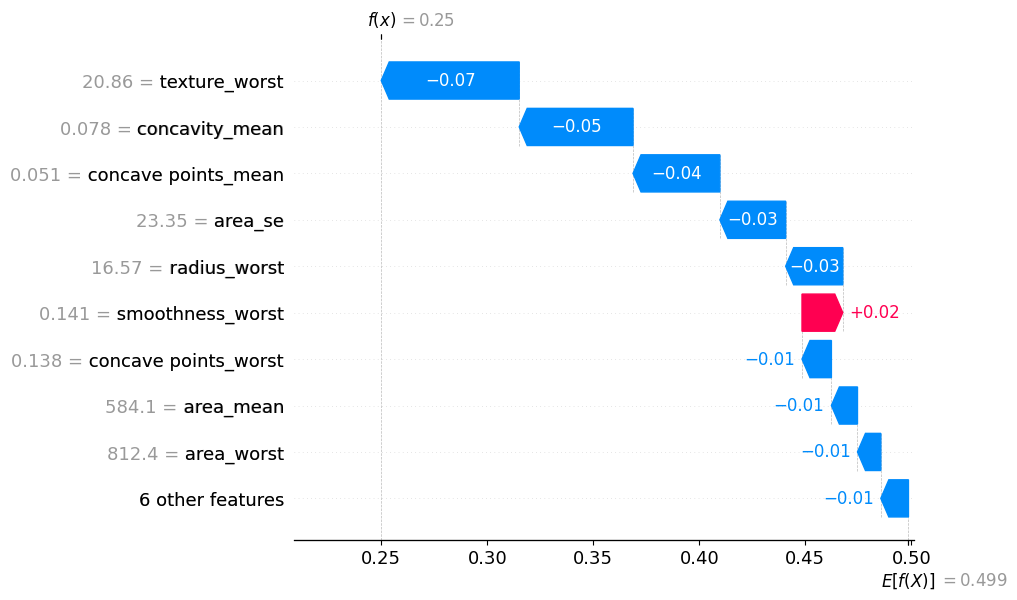


── False negative 2 ──


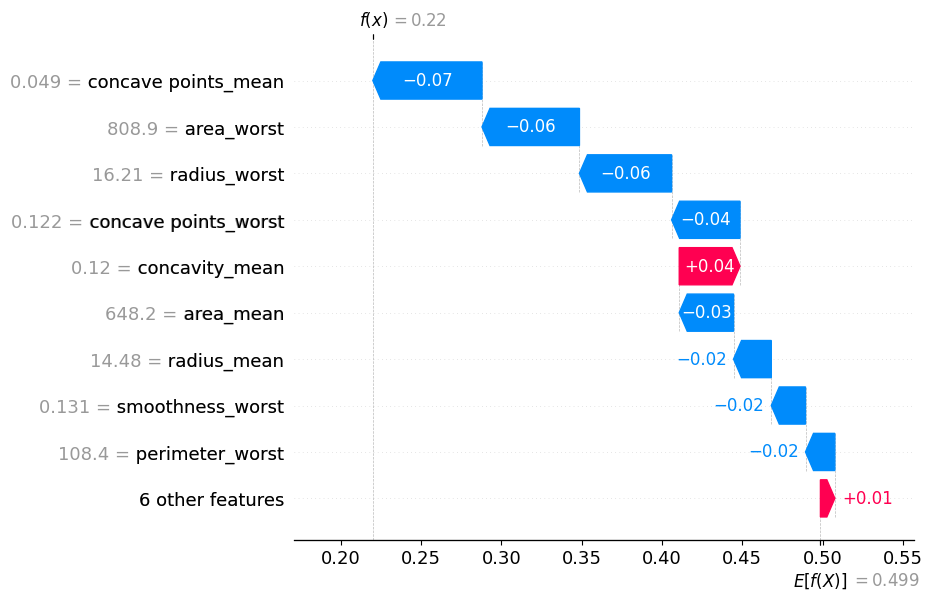


── False negative 3 ──


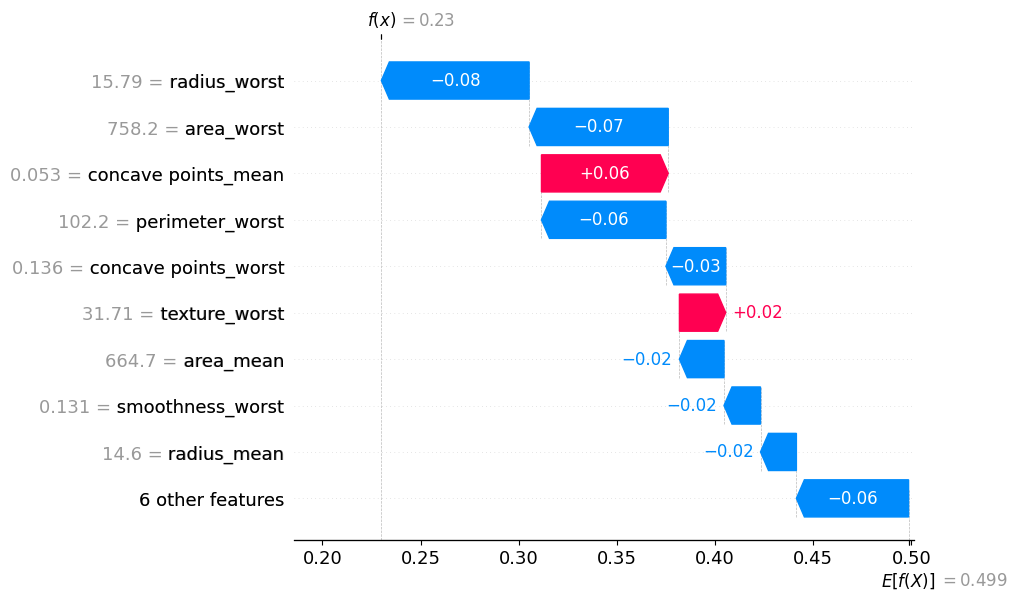

In [13]:
# ── Plot 1: Beeswarm summary ───────────────────────────────
shap.summary_plot(shap_malignant, X_test, plot_type="dot")

# ── Plot 2: Bar chart ──────────────────────────────────────
shap.summary_plot(shap_malignant, X_test, plot_type="bar")

# ── Plot 3: Single prediction ──────────────────────────────
# ── Get base value safely ──────────────────────────────────
ev = explainer.expected_value
base_val = float(ev[1]) if hasattr(ev, '__len__') else float(ev)

# ── Plot 3: Single prediction ──────────────────────────────
sample_index = 0
shap.waterfall_plot(
    shap.Explanation(
        values=shap_malignant[sample_index],
        base_values=base_val,
        data=X_test.iloc[sample_index].values,
        feature_names=X_test.columns.tolist()
    )
)

# ── Plot 4: The 3 false negatives ─────────────────────────
false_negatives = (y_test.values == 1) & (y_pred == 0)
fn_indices = np.where(false_negatives)[0]

for i, idx in enumerate(fn_indices):
    print(f"\n── False negative {i+1} ──")
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_malignant[idx],
            base_values=base_val,
            data=X_test.iloc[idx].values,
            feature_names=X_test.columns.tolist()
        )
    )

In [14]:
import joblib, json

# Export model
joblib.dump(model, "model.pkl")

# Export training data (SHAP needs this as background)
joblib.dump(X_train, "X_train.pkl")

# Export feature lists
with open("feature_names.json", "w") as f:
    json.dump({
        "all_features": top_features,   # all 15 the model was trained on
        "top5": importances.head(5).index.tolist()
    }, f)

print("Done — download these 3 files from Kaggle's output panel")

Done — download these 3 files from Kaggle's output panel
